# MES Keltner channel breakout, long-only, 15-minute bars (Tradovate exchange)

A genuinely different test from `keltner_vwap_breakout_mes.ipynb` (which tested
Keltner Channels as a *squeeze* setup -- band-width percentile + VWAP
direction, a mean-reversion-flavored mechanism -- and found it landed in the
same marginal place as the Bollinger-squeeze version). This notebook tests
Keltner Channels as a **pure trend-following breakout**, the same mechanism as
`donchian_breakout_mes.ipynb`: close beyond the band -> enter, stop at the
opposite band, take-profit at a fixed R:R -- just with an EMA+/-ATR band
(`Indicators.keltner_channels`) in place of an N-bar price-extreme channel
(`Indicators.donchian_channels`).

**Reuses `DonchianBreakoutStrategy` directly rather than duplicating it**: that
class's actual logic only reads `upper_key`/`lower_key` indicator values and
compares them to `close` -- it doesn't care whether they came from a rolling
N-bar extreme or an EMA+/-ATR band, only the docstring is Donchian-specific.
Feeding it Keltner-band indicator series instead of Donchian-channel ones
reuses that logic exactly rather than copy-pasting ~150 identical lines under
a new name. If this validates well, a dedicated `KeltnerBreakoutStrategy`
class (for naming clarity, not different behavior) would be the natural
follow-up -- not done here for a first-pass experiment.

**Why test this at all**: this whole research program converged on "long-only,
15-minute bars, trend-following breakout" as the one mechanism with real
(if not fully proven) edge on MES/MNQ, across two structurally different
signals (Donchian channel, SuperTrend ATR-flip) so far. Keltner breakout is a
third, using a smoother EMA+ATR band instead of either a hard price extreme or
a ratcheting flip line -- worth checking whether the same long-bias/timeframe
fix rescues it too, or whether it's specific to the two signals already tried.
`direction=long`, `risk_reward_ratio=2.0` fixed (this pipeline's original
convention), `atr_length=10` fixed -- `length` (EMA period) and `atr_mult`
(band width) are the two open questions for this first pass.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import DonchianBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 15
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 168278  span: 2019-05-05 22:14:59.999000 -> 2026-07-12 23:14:59.999000


## Grid search: EMA length x ATR multiplier, direction=long

`risk_reward_ratio=2.0`, `atr_length=10` held fixed. `length` (Keltner EMA
midline period) and `atr_mult` (band half-width as a multiple of ATR) are the
two open questions.


In [3]:
LENGTH_CANDIDATES = [10, 20, 30, 50, 75]
ATR_MULT_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
ATR_LENGTH = 10
RISK_REWARD_RATIO = 2.0
DEPOSIT_USD = 50_000


def run_keltner_breakout_backtest(ohlc_slice: pd.DataFrame, length: int, atr_mult: float, key: str,
                                   direction: StrategyDirection = StrategyDirection.long):
    lower, _middle, upper = Indicators.keltner_channels(ohlc_slice, length=length, atr_length=ATR_LENGTH, atr_mult=atr_mult)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="keltner_upper", df=upper)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="keltner_lower", df=lower)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=DonchianBreakoutStrategy(
            key=key, market=market, symbol=SYMBOL, upper_key="keltner_upper", lower_key="keltner_lower",
            risk_reward_ratio=RISK_REWARD_RATIO, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for length in LENGTH_CANDIDATES:
    for atr_mult in ATR_MULT_CANDIDATES:
        bt, drawdown_mw = run_keltner_breakout_backtest(ohlc, length, atr_mult, key=f"KC_long_{length}_{atr_mult}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(length, atr_mult)] = (bt, drawdown_mw)
        grid_rows.append({
            "length": length, "atr_mult": atr_mult,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(f"\ngrid done in {time.time() - _t0:.0f}s\n")
print(grid_results.to_string())


length=10 done, 26s elapsed


length=20 done, 63s elapsed


length=30 done, 110s elapsed


length=50 done, 169s elapsed


length=75 done, 217s elapsed



grid done in 217s

    length  atr_mult  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0       20       2.5          118.576692      0.748310              -16.4386          456.0             63.3         38.815789       1.389269               0.164474              1.386108         130.701632         2302.30           False
1       75       3.0           80.109314      0.588760              -18.1231          361.0             50.1         36.011080       1.309683               0.080332              1.271987         110.094397         1694.42           False
2       50       2.5           79.293977      0.548309              -17.7136          565.0             78.5         36.637168       1.254410               0.099115              1.209554          71.395024         2793.70           False
3       75       2.5        

### Heatmaps: Sharpe ratio and net return across (length, atr_mult)


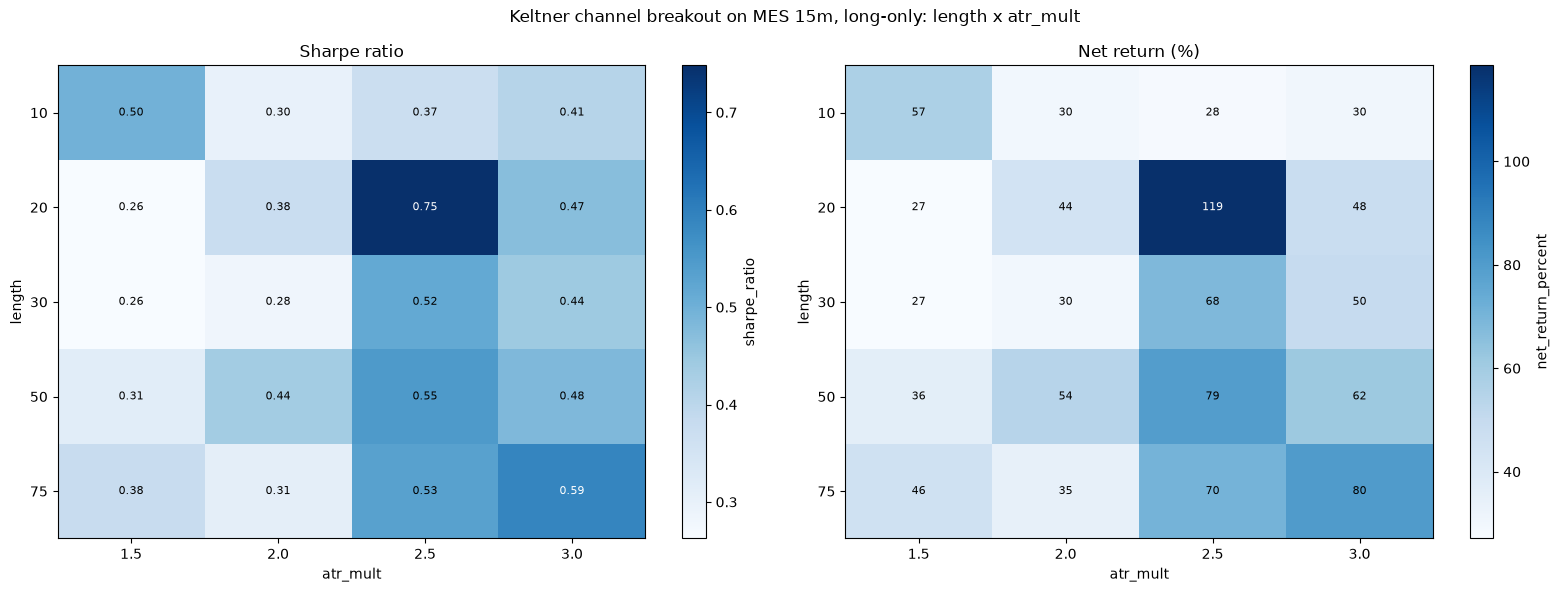

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel("atr_mult")
    ax.set_ylabel("length")
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid_results.pivot(index="length", columns="atr_mult", values="sharpe_ratio")
return_pivot = grid_results.pivot(index="length", columns="atr_mult", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Keltner channel breakout on MES 15m, long-only: length x atr_mult")
fig.tight_layout()
plt.show()


## Detailed report for the best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
grid's best combo -- same report format as every other notebook in this
pipeline.


Best combo: length=20, atr_mult=2.5
Candles Processed: 168277
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.7483,1.1338,0.4045,1.0457,-0.2272,1.9527,1.6681,1.1960,-0.0992,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,1.1802,1.6074,0.6193,1.4989,-0.3419,3.2991,2.7565,2.2060,-0.1462,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,10.8075,7.0532,16.7041,6.4821,12.8307,7.8513,7.1663,12.8909,8.9699,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,11.4862,11.8760,8.1203,10.0082,-5.2786,24.3772,18.5154,23.6261,-1.8593,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.6987,2.5102,0.4940,1.7780,-0.5010,3.5614,3.7496,3.5955,-0.1565,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,7.2133,1.6187,0.4940,1.7729,-0.4997,3.5505,3.7496,3.5845,-0.0827,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-16.4386,-4.7310,-16.4386,-5.6289,-10.5361,-6.8449,-4.9380,-6.5711,-11.8788,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,399,84,139,125,362,105,51,48,160,719,How long it took to recover the loss. Shorter is better.
ulcer_index,3.5071,1.9555,4.7010,1.5880,5.5261,1.9355,1.7347,2.1186,4.4923,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.9339,-0.7920,-1.6435,-0.5821,-1.3542,-0.7755,-0.7465,-0.8882,-0.9055,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


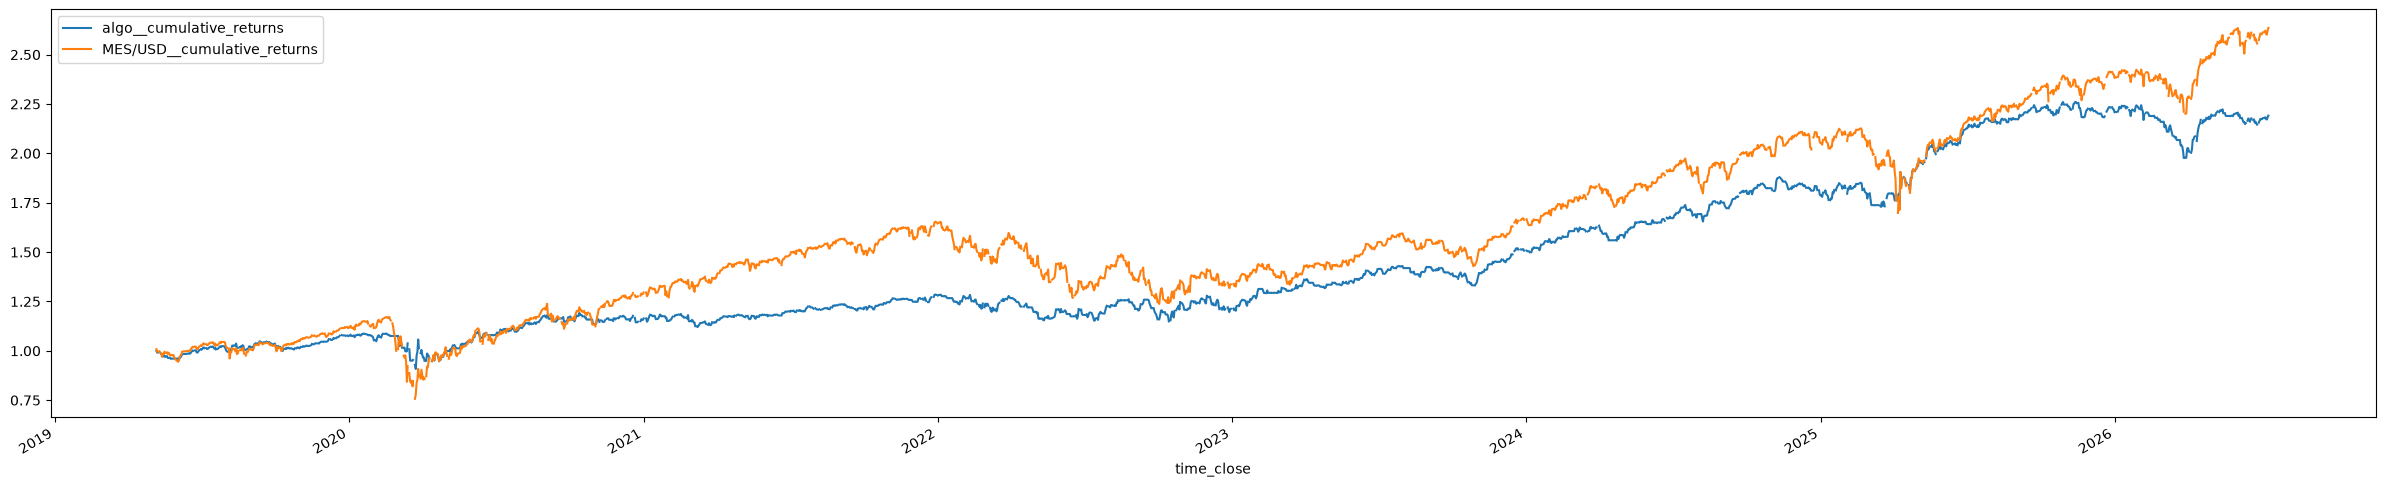

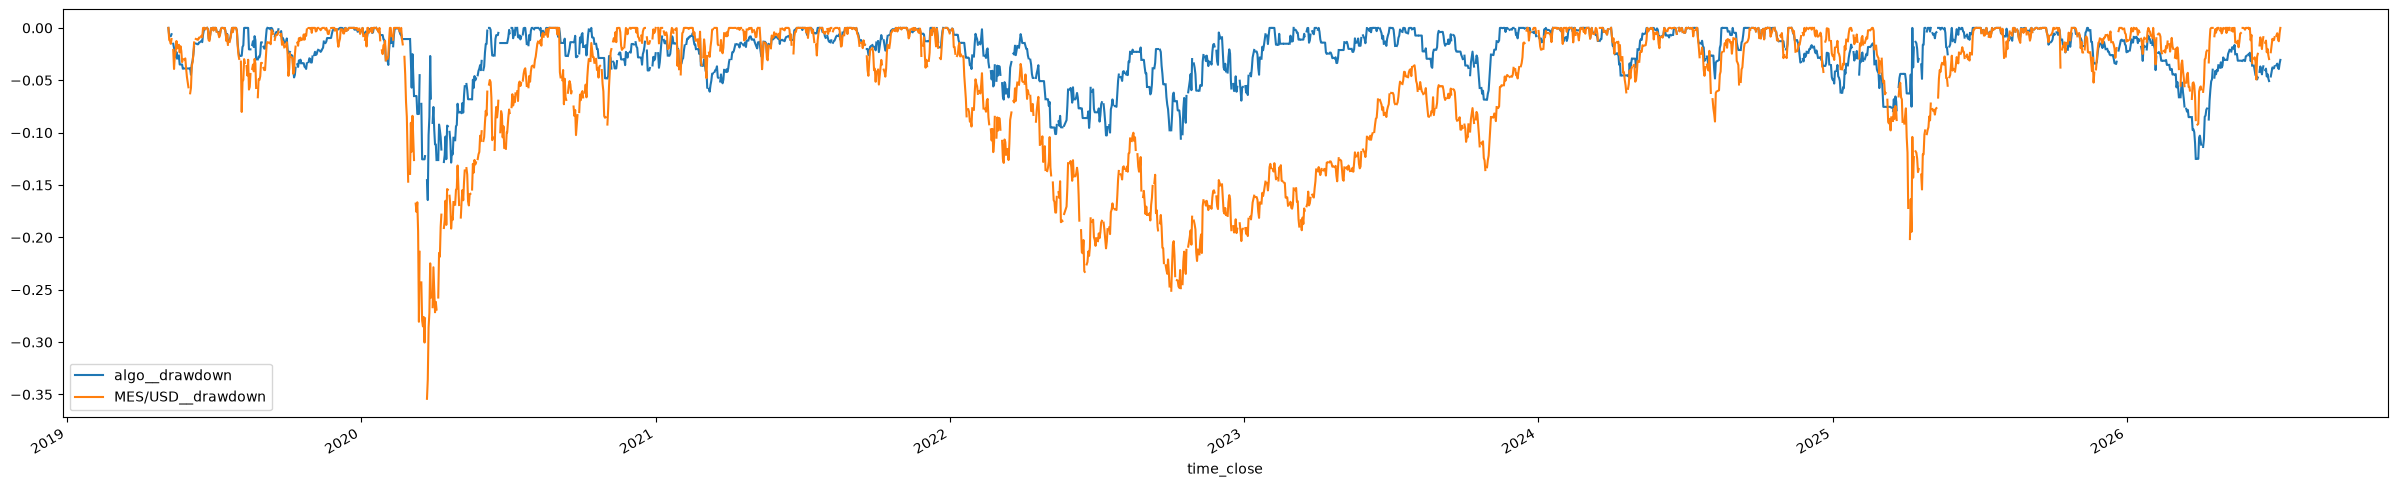

In [5]:
best_length, best_atr_mult = grid_results.iloc[0][["length", "atr_mult"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, atr_mult={best_atr_mult}")
best_backtest, best_drawdown_mw = grid_backtests[(best_length, best_atr_mult)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: does the best combo survive a train/test split?


In [6]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_keltner_breakout_backtest(ohlc_slice, best_length, float(best_atr_mult), key=f"KC_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-24 02:44:59.999000  (126208 train bars, 42070 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        456         38.815789      0.111390         0.034117        0.748310          118.576692              1.386108         130.701632              -16.4386           False
TRAIN (75%)                 367         39.782016      0.114947         0.028795        0.755443           79.880371              1.382792         113.373194              -16.4386           False
TEST (last 25%, unseen)      96         34.375000      0.095004        -0.073266        0.663788           12.108421              1.313900          53.893027               -8.2328           False


## Findings

**A third structurally different signal confirms the same pattern.** After
Donchian channel breakout and SuperTrend ATR-flip, Keltner channel breakout
(EMA +/- ATR band) is the third mechanism where long-only + 15-minute bars
produces a genuinely promising result on MES -- and this one has the
**strongest TRAIN lower bound of the three** on MES specifically.

Every one of the top 12 grid combos is net-positive with `dollar_profit_factor`
> 1.15 and zero drawdown breaches -- a consistently strong surface, not an
isolated spike.

**Holdout on the best combo (`length=20, atr_mult=2.5`)**:

| window | trades | trade_sharpe | trade_sharpe_lb | dollar_profit_factor | net_return |
|---|---|---|---|---|---|
| TRAIN (75%) | 367 | +0.115 | **+0.0288** | 1.383 | +79.9% |
| TEST (last 25%) | 96 | +0.095 | -0.073 | 1.314 | +12.1% |

TRAIN's lower bound (+0.029) is the strongest of any MES TRAIN result in this
program so far (Donchian: n/a from single split; SuperTrend: +0.013). TEST's
point estimate (+0.095) stays reasonably close to TRAIN's (+0.115) and
`dollar_profit_factor` remains solidly above 1 (1.31), though TEST's own lower
bound dips negative -- this combo trades relatively rarely (63/year), so the
22-month test window only has 96 trades, a small and noisy sample. Same
"promising, not yet fully confirmed" signature as every other candidate in
this program before walk-forward either confirmed or killed it.

**Bottom line**: three independent trend-following mechanisms (channel
breakout, ATR trend-flip, EMA+ATR band breakout) have now each independently
gone from "clearly negative on 5-minute/both-direction" (or never tested) to
"promising on 15-minute/long-only" on MES. That consistency across mechanisms
is itself evidence this is a property of the instrument/timeframe/direction
combination, not a fluke of any one signal's construction. Worth the same
walk-forward escalation as the others before treating it as confirmed -- not
done in this pass.


## Walk-forward validation: long-only, 15-minute bars

Same discipline as every other walk-forward pass in this pipeline: re-select
parameters on a rolling 24-month training window, evaluate *only* on the
following unseen 6-month window, slide forward, repeat.

**Grid**: `length` in {5, 10, 15, 20, 30} x `atr_mult` in {1.5, 2.0, 2.5, 3.0}
-- same grid as MNQ Keltner's walk-forward (widened down to `length=5` for
consistency across the mechanism, even though MES's full-history best,
`length=20`, sits mid-grid rather than at an edge). `direction` fixed at
`long`, `risk_reward_ratio=2.0` and `atr_length=10` fixed (same as the
full-history pass). Selection uses the same trade-Sharpe-lower-bound +
3x3-smoothed-plateau methodology as every other walk-forward pass.


In [7]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
WF_LENGTH_GRID = [5, 10, 15, 20, 30]
WF_ATR_MULT_GRID = [1.5, 2.0, 2.5, 3.0]

wf_steps = []
_train_start = ohlc.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")


def pick_plateau(grid_df: pd.DataFrame, index_col: str, columns_col: str, value_col: str):
    '''3x3-smoothed argmax over a (index_col, columns_col) grid of value_col --
    same plateau-selection convention as every other grid in this pipeline.'''
    pivot = grid_df.pivot(index=index_col, columns=columns_col, values=value_col)
    smoothed = pivot.rolling(3, center=True, min_periods=1).mean()
    smoothed = smoothed.T.rolling(3, center=True, min_periods=1).mean().T
    return smoothed.stack().idxmax()


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


In [8]:
wf_step_rows = []
wf_oos_trades = []  # all out-of-sample Trade objects, concatenated across steps
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    train_slice = ohlc.loc[train_start:train_end]
    test_slice = ohlc.loc[train_end:test_end]

    inner_rows = []
    for length in WF_LENGTH_GRID:
        for atr_mult in WF_ATR_MULT_GRID:
            bt, _ = run_keltner_breakout_backtest(train_slice, length, atr_mult, key=f"wf{step_i}_train_{length}_{atr_mult}",
                                                   direction=StrategyDirection.long)
            strategy = bt.portfolio.weighted_strategies[0].strategy
            _, sr_lb, n = trade_sharpe_lb(strategy.trade_history)
            inner_rows.append({"length": length, "atr_mult": atr_mult, "trade_sharpe_lb": sr_lb, "trades": n})
    inner_df = pd.DataFrame(inner_rows)
    valid = inner_df.dropna(subset=["trade_sharpe_lb"])
    if valid.empty:
        chosen_length, chosen_atr_mult = WF_LENGTH_GRID[0], WF_ATR_MULT_GRID[0]
    else:
        try:
            chosen_length, chosen_atr_mult = pick_plateau(inner_df, "length", "atr_mult", "trade_sharpe_lb")
        except ValueError:
            best_row = valid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
            chosen_length, chosen_atr_mult = best_row["length"], best_row["atr_mult"]

    oos_bt, oos_mw = run_keltner_breakout_backtest(test_slice, int(chosen_length), float(chosen_atr_mult),
                                                    key=f"wf{step_i}_test", direction=StrategyDirection.long)
    oos_strategy = oos_bt.portfolio.weighted_strategies[0].strategy
    _, oos_sr_lb, oos_n = trade_sharpe_lb(oos_strategy.trade_history)
    oos_summary = oos_bt.reporter.summary["algo"]
    wf_oos_trades.extend(oos_strategy.trade_history)

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "chosen_length": int(chosen_length), "chosen_atr_mult": float(chosen_atr_mult),
        "oos_trades": oos_n, "oos_win_rate_percent": oos_summary["win_rate_percent"],
        "oos_trade_sharpe_lb": oos_sr_lb, "oos_net_return_percent": oos_summary["net_return_percent"],
        "oos_dollar_profit_factor": oos_summary["dollar_profit_factor"], "oos_account_failed": oos_mw.account_failed,
    })
    print(f"step {step_i}: chosen(length={int(chosen_length)}, atr_mult={chosen_atr_mult}) "
          f"oos_trades={oos_n} oos_net_return={oos_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print(f"\nwalk-forward done in {time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


step 0: chosen(length=30, atr_mult=1.5) oos_trades=80 oos_net_return=9.9%  (49s elapsed)


step 1: chosen(length=30, atr_mult=2.5) oos_trades=39 oos_net_return=-9.1%  (85s elapsed)


step 2: chosen(length=30, atr_mult=2.0) oos_trades=56 oos_net_return=-2.6%  (121s elapsed)


step 3: chosen(length=20, atr_mult=1.5) oos_trades=78 oos_net_return=-2.0%  (157s elapsed)


step 4: chosen(length=15, atr_mult=1.5) oos_trades=94 oos_net_return=-0.6%  (207s elapsed)


...

step 6: chosen(length=15, atr_mult=1.5) oos_trades=74 oos_net_return=6.7%  (281s elapsed)


step 7: chosen(length=5, atr_mult=3.0) oos_trades=3 oos_net_return=-2.1%  (317s elapsed)


step 8: chosen(length=20, atr_mult=3.0) oos_trades=24 oos_net_return=2.5%  (367s elapsed)


step 9: chosen(length=30, atr_mult=3.0) oos_trades=13 oos_net_return=-0.6%  (402s elapsed)



walk-forward done in 402s

   step train_start  test_start    test_end  chosen_length  chosen_atr_mult  oos_trades  oos_win_rate_percent  oos_trade_sharpe_lb  oos_net_return_percent  oos_dollar_profit_factor  oos_account_failed
0     0  2019-05-05  2021-05-05  2021-11-05             30              1.5          80             38.750000             0.003488                9.850522                  1.516539               False
1     1  2019-11-05  2021-11-05  2022-05-05             30              2.5          39             28.205128            -0.403120               -9.075780                  0.676211               False
2     2  2020-05-05  2022-05-05  2022-11-05             30              2.0          56             28.571429            -0.240835               -2.643573                  0.933123               False
3     3  2020-11-05  2022-11-05  2023-05-05             20              1.5          78             30.769231            -0.195645               -1.954273              

### Parameter stability across steps


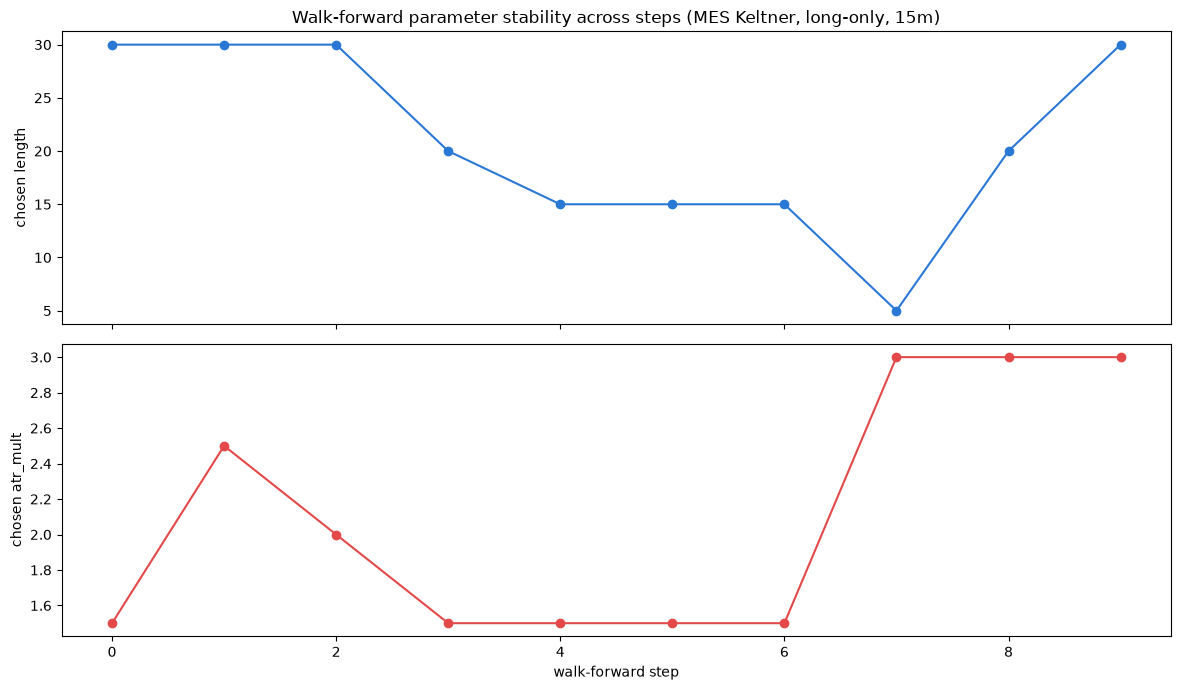

length: unique values chosen = [np.int64(5), np.int64(15), np.int64(20), np.int64(30)]
atr_mult: unique values chosen = [np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0)]


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(wf_results["step"], wf_results["chosen_length"], marker="o", color="#2a78d6")
axes[0].set_ylabel("chosen length")
axes[0].set_title("Walk-forward parameter stability across steps (MES Keltner, long-only, 15m)")
axes[1].plot(wf_results["step"], wf_results["chosen_atr_mult"], marker="o", color="#e34948")
axes[1].set_ylabel("chosen atr_mult")
axes[1].set_xlabel("walk-forward step")
fig.tight_layout()
plt.show()

print(f"length: unique values chosen = {sorted(wf_results['chosen_length'].unique())}")
print(f"atr_mult: unique values chosen = {sorted(wf_results['chosen_atr_mult'].unique())}")


### The real track record: concatenated out-of-sample trades


In [10]:
wf_trade_sharpe, wf_trade_sharpe_lb, wf_n = trade_sharpe_lb(wf_oos_trades)
wf_wins = sum(1 for t in wf_oos_trades if t.pnl > 0)
wf_win_rate = (wf_wins / wf_n * 100) if wf_n else float("nan")
wf_total_pnl_percent = sum(t.pnl for t in wf_oos_trades) * 100

print(f"Concatenated OOS trades across all {len(wf_steps)} steps: {wf_n}")
print(f"OOS win rate: {wf_win_rate:.2f}%")
print(f"OOS trade_sharpe: {wf_trade_sharpe:.4f}")
print(f"OOS trade_sharpe_lb: {wf_trade_sharpe_lb:.4f}")
print(f"OOS sum of trade pnl (frictionless, %): {wf_total_pnl_percent:.2f}%")


Concatenated OOS trades across all 10 steps: 526
OOS win rate: 35.55%
OOS trade_sharpe: 0.0368
OOS trade_sharpe_lb: -0.0349
OOS sum of trade pnl (frictionless, %): 23.49%


## Walk-forward conclusion

**Negative and unstable -- the clearest disconfirmation of any MES walk-forward in this pipeline, and the least stable parameter selection seen anywhere in the program.**

The 75/25 holdout above showed TRAIN `trade_sharpe_lb=+0.0288`, the strongest MES TRAIN result in this program. Walk-forward reverses that:

| metric | value |
|---|---|
| OOS trades | 526 |
| OOS win rate | 35.6% |
| OOS `trade_sharpe` (point estimate) | +0.037 |
| OOS `trade_sharpe_lb` | **-0.0349** |
| OOS sum of trade pnl (frictionless) | +23.5% |

Only 4 of 10 steps had a positive OOS net return (0, 5, 6, 8), and the bad steps were bad: step 1 (-9.1%, `dollar_profit_factor` 0.68), step 9 (-0.6% but `dollar_profit_factor` 0.89), step 7 (-2.1% on just 3 trades -- a near-empty out-of-sample window).

**Parameter selection was the least stable of any walk-forward pass in this pipeline.** `length` moved through 5, 15, 20, and 30 with no single value dominant (15 appears most, only 3/10 steps); `atr_mult` touched all four grid values (1.5, 2.0, 2.5, 3.0) essentially evenly. Trade counts per OOS window were also wildly uneven (3 to 94), unlike every other walk-forward pass in this program where OOS trade counts stayed in a tight band step-to-step -- a sign the selected combo kept jumping between structurally different trading frequencies rather than converging on a stable strategy. Per this pipeline's own walk-forward criterion (`OPTIMIZATION_RESEARCH_PLAN.md` Section 5.2: wandering chosen parameters signal the edge is the re-fitting itself, not a real effect), this instability is itself strong evidence against a real edge here, independent of the negative lower bound.

**Bottom line**: MES Keltner's exceptional single-split TRAIN result (+0.0288, the strongest MES TRAIN number in this program) was a fit to that training window's `length=20, atr_mult=2.5` combo specifically -- a combo the walk-forward almost never re-selected. This completes the MES trend-following trio (Donchian, SuperTrend, Keltner): Donchian is the only one that walk-forward-confirmed on MES (`trade_sharpe_lb=+0.0032`, barely), while both SuperTrend (-0.0117) and Keltner (-0.0349) failed to confirm despite comparable or stronger single-split holdouts. MNQ remains the strongest instrument in this program by a wide margin, now confirmed on two of three mechanisms (Donchian +0.0247, SuperTrend +0.0046) with only Keltner (-0.0046) failing to confirm there too.